# Music Genre Classification

## Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import KFold

Pandas version: 1.4.4
NumPy version: 1.23.5


## Thiết lập thư số và đường dẫn

In [2]:
data_dir = '../../../data/music_genre'
output_dir = '../../../exps3/featbase_3'
os.makedirs(output_dir, exist_ok=True)

print("Directories created successfully!")

contents = os.listdir(data_dir)
for item in contents:
    print(f"  - {item}")

Directories created successfully!
  - sample_submission (2).csv
  - test(2).csv
  - train(1).csv


## Load và khám phá dữ liệu

In [3]:
train_df = pd.read_csv(f'{data_dir}/train(1).csv')
test_df = pd.read_csv(f'{data_dir}/test(2).csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())

Train shape: (14396, 18)
Test shape: (3600, 17)

Train columns: ['Id', 'Artist Name', 'Track Name', 'Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Class']


## Lưu dữ liệu gốc

In [4]:
train_df.to_csv(f'{output_dir}/01_original_train.csv', index=False)
test_df.to_csv(f'{output_dir}/01_original_test.csv', index=False)

print("Original data saved!")

Original data saved!


### Thông tin cơ bản về dữ liệu

In [5]:
print("Train info:")
train_df.info()

print(f"\nMissing values in train: {train_df.isnull().sum().sum()}")
print(f"Missing values in test: {test_df.isnull().sum().sum()}")

print("\nTarget distribution:")
print(train_df['Class'].value_counts().sort_index())

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396 non-null  float

### Phân tích missing values chi tiết

In [6]:
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()

print("Missing values per column in train:")
print(missing_train[missing_train > 0])
print("\nMissing values per column in test:")
print(missing_test[missing_test > 0])

Missing values per column in train:
Popularity           333
key                 1609
instrumentalness    3541
dtype: int64

Missing values per column in test:
Popularity           95
key                 405
instrumentalness    836
dtype: int64


## Data Preprocessing

In [7]:
train_processed = train_df.copy()
test_processed = test_df.copy()

In [8]:
# Xử lý missing values
print("\n=== HANDLING MISSING VALUES ===")

for col in train_processed.columns:
    if train_processed[col].isnull().sum() > 0:
        if train_processed[col].dtype in ['int64', 'float64']:
            # Numeric columns - điền median
            fill_value = train_processed[col].median()
            print(f"Filling {col} (numeric) with median: {fill_value}")
        else:
            # Categorical columns - điền mode
            fill_value = train_processed[col].mode()[0] if len(train_processed[col].mode()) > 0 else 'Unknown'
            print(f"Filling {col} (categorical) with mode: {fill_value}")
        
        train_processed[col].fillna(fill_value, inplace=True)
        test_processed[col].fillna(fill_value, inplace=True)

print(f"\nAfter filling - Missing values in train: {train_processed.isnull().sum().sum()}")
print(f"After filling - Missing values in test: {test_processed.isnull().sum().sum()}")


=== HANDLING MISSING VALUES ===
Filling Popularity (numeric) with median: 44.0
Filling key (numeric) with median: 6.0
Filling instrumentalness (numeric) with median: 0.00392

After filling - Missing values in train: 0
After filling - Missing values in test: 0


In [9]:
# Lưu dữ liệu sau khi xử lý missing values
train_processed.to_csv(f'{output_dir}/02_after_missing_values_train.csv', index=False)
test_processed.to_csv(f'{output_dir}/02_after_missing_values_test.csv', index=False)
print("Data after missing value handling saved!")

Data after missing value handling saved!


In [10]:
print("\n=== DATA AFTER PREPROCESSING ===")
print("Train data types:")
print(train_processed.dtypes.value_counts())
print(f"\nTrain shape: {train_processed.shape}")
print(f"Test shape: {test_processed.shape}")


=== DATA AFTER PREPROCESSING ===
Train data types:
float64    12
int64       4
object      2
dtype: int64

Train shape: (14396, 18)
Test shape: (3600, 17)


In [11]:
# Encoding categorical variables
print("\n=== ENCODING CATEGORICAL VARIABLES ===")

cat_columns = train_processed.select_dtypes(include=['object']).columns
print(f"Categorical columns to encode: {list(cat_columns)}")

for col in cat_columns:
    if col != 'Class':  # Class là target, không encode
        # Combine train và test để fit encoder
        combined = pd.concat([train_processed[col], test_processed[col]], axis=0).astype(str)
        le = LabelEncoder()
        le.fit(combined)
        
        # Transform cả train và test
        train_processed[col] = le.transform(train_processed[col].astype(str))
        test_processed[col] = le.transform(test_processed[col].astype(str))
        
        print(f"Encoded {col} - {len(le.classes_)} unique values")


=== ENCODING CATEGORICAL VARIABLES ===
Categorical columns to encode: ['Artist Name', 'Track Name']
Encoded Artist Name - 9149 unique values
Encoded Track Name - 15129 unique values


In [12]:
train_processed.to_csv(f'{output_dir}/03_after_encoding_train.csv', index=False)
test_processed.to_csv(f'{output_dir}/03_after_encoding_test.csv', index=False)
print("Data after encoding saved!")

Data after encoding saved!


In [13]:
# Thống kê dữ liệu sau preprocessing
print("\n=== DATA AFTER PREPROCESSING ===")
print("Train data types:")
print(train_processed.dtypes.value_counts())
print(f"\nTrain shape: {train_processed.shape}")
print(f"Test shape: {test_processed.shape}")


=== DATA AFTER PREPROCESSING ===
Train data types:
float64    12
int64       4
int32       2
dtype: int64

Train shape: (14396, 18)
Test shape: (3600, 17)


## Feature Engineering

### Feature Extraction

In [14]:
train_engineered = train_df.copy()
test_engineered = test_df.copy()

# 1.1. Tạo features từ tempo và duration (quan trọng cho âm nhạc)
train_engineered['tempo_per_minute'] = train_engineered['tempo'] / 60
test_engineered['tempo_per_minute'] = test_engineered['tempo'] / 60

train_engineered['beats_per_track'] = train_engineered['tempo'] * train_engineered['duration_in min/ms'] / 60
test_engineered['beats_per_track'] = test_engineered['tempo'] * test_engineered['duration_in min/ms'] / 60

# 1.2. Tạo energy-danceability ratio (EDR) - đặc trưng quan trọng cho thể loại nhạc
train_engineered['energy_danceability_ratio'] = train_engineered['energy'] / (train_engineered['danceability'] + 1e-10)
test_engineered['energy_danceability_ratio'] = test_engineered['energy'] / (test_engineered['danceability'] + 1e-10)

# 1.3. Tạo acoustic-energy balance (phân biệt nhạc acoustic vs electronic)
train_engineered['acoustic_energy_balance'] = train_engineered['acousticness'] * train_engineered['energy']
test_engineered['acoustic_energy_balance'] = test_engineered['acousticness'] * test_engineered['energy']

# 1.4. Tạo valence-energy interaction (tâm trạng và năng lượng)
train_engineered['valence_energy_interaction'] = train_engineered['valence'] * train_engineered['energy']
test_engineered['valence_energy_interaction'] = test_engineered['valence'] * test_engineered['energy']

# 1.5. Tạo speechiness-instrumentalness balance (phân biệt nhạc có lời vs không lời)
train_engineered['speech_instrument_balance'] = train_engineered['speechiness'] / (train_engineered['instrumentalness'] + 1e-10)
test_engineered['speech_instrument_balance'] = test_engineered['speechiness'] / (test_engineered['instrumentalness'] + 1e-10)

# 1.6. Tạo features tổng hợp cho các đặc trưng âm thanh
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 'valence']

# Tạo composite score cho audio features
train_engineered['audio_composite_score'] = train_engineered[audio_features].mean(axis=1)
test_engineered['audio_composite_score'] = test_engineered[audio_features].mean(axis=1)

# 1.7. Tạo rhythmic complexity score (phức tạp nhịp điệu)
train_engineered['rhythmic_complexity'] = train_engineered['danceability'] * train_engineered['energy'] * train_engineered['tempo'] / 100
test_engineered['rhythmic_complexity'] = test_engineered['danceability'] * test_engineered['energy'] * test_engineered['tempo'] / 100

# 1.8. Tạo emotional intensity score (cường độ cảm xúc)
train_engineered['emotional_intensity'] = (train_engineered['valence'] * 2 + train_engineered['energy'] * 3) / 5
test_engineered['emotional_intensity'] = (test_engineered['valence'] * 2 + test_engineered['energy'] * 3) / 5

### BINNING & CATEGORICAL TRANSFORMATION

In [15]:
# 2.1. Bin tempo vào các categories âm nhạc
tempo_bins = [0, 60, 80, 100, 120, 140, 160, 180, 200, 250, 300]
tempo_labels = ['largo', 'adagio', 'andante', 'moderato', 'allegro', 'vivace', 'presto', 'prestissimo', 'hyper', 'ultra']
train_engineered['tempo_category'] = pd.cut(train_engineered['tempo'], bins=tempo_bins, labels=tempo_labels)
test_engineered['tempo_category'] = pd.cut(test_engineered['tempo'], bins=tempo_bins, labels=tempo_labels)

# Encode tempo_category
le_tempo = LabelEncoder()
combined_tempo = pd.concat([train_engineered['tempo_category'], test_engineered['tempo_category']])
le_tempo.fit(combined_tempo.astype(str))
train_engineered['tempo_category_encoded'] = le_tempo.transform(train_engineered['tempo_category'].astype(str))
test_engineered['tempo_category_encoded'] = le_tempo.transform(test_engineered['tempo_category'].astype(str))

# 2.2. Bin duration thành các nhóm
duration_bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 30, 50, 100]
duration_labels = ['very_short', 'short', 'medium_short', 'medium', 'medium_long', 
                   'long', 'very_long', 'extended', 'epic', 'super_epic', 'mega_epic', 'ultra_epic', 'legendary', 'mythic']
train_engineered['duration_category'] = pd.cut(train_engineered['duration_in min/ms'], bins=duration_bins, labels=duration_labels)
test_engineered['duration_category'] = pd.cut(test_engineered['duration_in min/ms'], bins=duration_bins, labels=duration_labels)

# Encode duration_category
le_duration = LabelEncoder()
combined_duration = pd.concat([train_engineered['duration_category'], test_engineered['duration_category']])
le_duration.fit(combined_duration.astype(str))
train_engineered['duration_category_encoded'] = le_duration.transform(train_engineered['duration_category'].astype(str))
test_engineered['duration_category_encoded'] = le_duration.transform(test_engineered['duration_category'].astype(str))

# 2.3. Bin energy levels
energy_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
energy_labels = ['very_low', 'low', 'medium', 'high', 'very_high']
train_engineered['energy_level'] = pd.cut(train_engineered['energy'], bins=energy_bins, labels=energy_labels)
test_engineered['energy_level'] = pd.cut(test_engineered['energy'], bins=energy_bins, labels=energy_labels)

# Encode energy_level
le_energy = LabelEncoder()
combined_energy = pd.concat([train_engineered['energy_level'], test_engineered['energy_level']])
le_energy.fit(combined_energy.astype(str))
train_engineered['energy_level_encoded'] = le_energy.transform(train_engineered['energy_level'].astype(str))
test_engineered['energy_level_encoded'] = le_energy.transform(test_engineered['energy_level'].astype(str))

# 2.4. Bin danceability levels
danceability_bins = [0, 0.3, 0.5, 0.7, 0.9, 1.0]
danceability_labels = ['very_low', 'low', 'medium', 'high', 'very_high']
train_engineered['danceability_level'] = pd.cut(train_engineered['danceability'], bins=danceability_bins, labels=danceability_labels)
test_engineered['danceability_level'] = pd.cut(test_engineered['danceability'], bins=danceability_bins, labels=danceability_labels)

# Encode danceability_level
le_danceability = LabelEncoder()
combined_danceability = pd.concat([train_engineered['danceability_level'], test_engineered['danceability_level']])
le_danceability.fit(combined_danceability.astype(str))
train_engineered['danceability_level_encoded'] = le_danceability.transform(train_engineered['danceability_level'].astype(str))
test_engineered['danceability_level_encoded'] = le_danceability.transform(test_engineered['danceability_level'].astype(str))

# 2.5. Tạo Popularity tiers
popularity_bins = [0, 20, 40, 60, 80, 100]
popularity_labels = ['unknown', 'low', 'medium', 'high', 'viral']
train_engineered['popularity_tier'] = pd.cut(train_engineered['Popularity'], bins=popularity_bins, labels=popularity_labels)
test_engineered['popularity_tier'] = pd.cut(test_engineered['Popularity'], bins=popularity_bins, labels=popularity_labels)

# Encode popularity_tier
le_popularity = LabelEncoder()
combined_popularity = pd.concat([train_engineered['popularity_tier'], test_engineered['popularity_tier']])
le_popularity.fit(combined_popularity.astype(str))
train_engineered['popularity_tier_encoded'] = le_popularity.transform(train_engineered['popularity_tier'].astype(str))
test_engineered['popularity_tier_encoded'] = le_popularity.transform(test_engineered['popularity_tier'].astype(str))


In [16]:
print(f"\nSố lượng features ban đầu: {len(train_df.columns)}")
print(f"Số lượng features sau engineering: {len(train_engineered.columns)}")


Số lượng features ban đầu: 18
Số lượng features sau engineering: 37


In [17]:
# Hiển thị các features mới
new_features = set(train_engineered.columns) - set(train_df.columns)
print(f"\nCác features mới được tạo ({len(new_features)} features):")
for i, feature in enumerate(sorted(new_features), 1):
    print(f"{i:2d}. {feature}")

# Lưu dữ liệu sau feature engineering
train_engineered.to_csv(f'{output_dir}/041_after_feature_engineering_train.csv', index=False)
test_engineered.to_csv(f'{output_dir}/041_after_feature_engineering_test.csv', index=False)
print("\nData after feature engineering saved!")


Các features mới được tạo (19 features):
 1. acoustic_energy_balance
 2. audio_composite_score
 3. beats_per_track
 4. danceability_level
 5. danceability_level_encoded
 6. duration_category
 7. duration_category_encoded
 8. emotional_intensity
 9. energy_danceability_ratio
10. energy_level
11. energy_level_encoded
12. popularity_tier
13. popularity_tier_encoded
14. rhythmic_complexity
15. speech_instrument_balance
16. tempo_category
17. tempo_category_encoded
18. tempo_per_minute
19. valence_energy_interaction

Data after feature engineering saved!


### Loại bỏ các đặc trưng không cần thiết

In [18]:
# Loại bỏ các đặc trưng không cần thiết
columns_to_drop = ['Id', 'Artist Name', 'Track Name']  # Các đặc trưng không mang tính phân loại

print("Columns to be dropped:", columns_to_drop)

# Kiểm tra xem các cột có tồn tại không
for col in columns_to_drop:
    if col in train_engineered.columns:
        print(f"Dropping column: {col}")
    else:
        print(f"Column {col} not found in dataset")

# Loại bỏ các cột không cần thiết
train_df_cleaned = train_engineered.drop(columns=[col for col in columns_to_drop if col in train_df.columns])
test_df_cleaned = test_engineered.drop(columns=[col for col in columns_to_drop if col in test_df.columns])

print(f"\nTrain shape after dropping columns: {train_df_cleaned.shape}")
print(f"Test shape after dropping columns: {test_df_cleaned.shape}")

Columns to be dropped: ['Id', 'Artist Name', 'Track Name']
Dropping column: Id
Dropping column: Artist Name
Dropping column: Track Name

Train shape after dropping columns: (14396, 34)
Test shape after dropping columns: (3600, 33)


In [19]:
# Lưu dữ liệu sau feature selection
train_df_cleaned.to_csv(f'{output_dir}/042_after_feature_selection_train.csv', index=False)
test_df_cleaned.to_csv(f'{output_dir}/042_after_feature_selection_test.csv', index=False)
print("Data after feature selection saved!")

Data after feature selection saved!


## Data Scaling

In [20]:
# Chuẩn bị dữ liệu cho training
X_train = train_df_cleaned.drop('Class', axis=1)
y_train = train_df_cleaned['Class']
X_test = test_df_cleaned.copy()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (14396, 33)
y_train shape: (14396,)
X_test shape: (3600, 33)


In [21]:
# Lưu features trước khi scaling
X_train.to_csv(f'{output_dir}/05_features_before_scaling_train.csv', index=False)
X_test.to_csv(f'{output_dir}/05_features_before_scaling_test.csv', index=False)
y_train.to_csv(f'{output_dir}/05_target_train.csv', index=False)
print("Features before scaling saved!")

Features before scaling saved!


In [22]:
# Xác định numerical và categorical columns
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"\nCategorical columns: {categorical_cols}")

# Tạo preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore'), categorical_cols)
    ])

# Fit và transform
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f"\nNaN in X_train_scaled: {np.isnan(X_train_scaled).sum()}")
print(f"NaN in X_test_scaled: {np.isnan(X_test_scaled).sum()}")

print(f"\nX_train_processed shape: {X_train_scaled.shape}")
print(f"X_test_processed shape: {X_test_scaled.shape}")

Numerical columns: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'tempo_per_minute', 'beats_per_track', 'energy_danceability_ratio', 'acoustic_energy_balance', 'valence_energy_interaction', 'speech_instrument_balance', 'audio_composite_score', 'rhythmic_complexity', 'emotional_intensity', 'tempo_category_encoded', 'duration_category_encoded', 'energy_level_encoded', 'danceability_level_encoded', 'popularity_tier_encoded']

Categorical columns: ['tempo_category', 'duration_category', 'energy_level', 'danceability_level', 'popularity_tier']

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0

X_train_processed shape: (14396, 61)
X_test_processed shape: (3600, 61)


In [23]:
# Lưu dữ liệu đã scaled
pd.DataFrame(X_train_scaled).to_csv(f'{output_dir}/06_features_after_scaling_train.csv', index=False)
pd.DataFrame(X_test_scaled).to_csv(f'{output_dir}/06_features_after_scaling_test.csv', index=False)
print("Scaled features saved!")

Scaled features saved!


## Model Training

In [24]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, learning_rate=0.1),
    'LightGBM': LGBMClassifier(random_state=42, n_estimators=100, learning_rate=0.1),
    'SVM': SVC(random_state=42, probability=True, kernel='rbf'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'MLP': MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=1000)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

results = {
    'Model': [],
    'Accuracy': [],
    'F1_Score': [],
    'ROC_AUC': [],
    'Fold_Accuracies': [],
    'Fold_F1_Scores': [],
    'Fold_ROC_AUCs': []
}

In [25]:
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    fold_accuracies = []
    fold_f1_scores = []
    fold_roc_aucs = []
    
    # Cross-validation
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_scaled, y_train), 1):
        X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Train model
        model.fit(X_train_fold, y_train_fold)
        
        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold) if hasattr(model, 'predict_proba') else None
        
        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        f1 = f1_score(y_val_fold, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_val_fold, y_pred_proba, multi_class='ovr') if y_pred_proba is not None else 0
        
        fold_accuracies.append(accuracy)
        fold_f1_scores.append(f1)
        fold_roc_aucs.append(roc_auc)
    
    # Tính trung bình các metrics
    avg_accuracy = np.mean(fold_accuracies)
    avg_f1 = np.mean(fold_f1_scores)
    avg_roc_auc = np.mean(fold_roc_aucs)
    
    # Lưu kết quả
    results['Model'].append(model_name)
    results['Accuracy'].append(avg_accuracy)
    results['F1_Score'].append(avg_f1)
    results['ROC_AUC'].append(avg_roc_auc)
    results['Fold_Accuracies'].append(fold_accuracies)
    results['Fold_F1_Scores'].append(fold_f1_scores)
    results['Fold_ROC_AUCs'].append(fold_roc_aucs)
    
    print(f"  Average Accuracy: {avg_accuracy:.4f}")
    print(f"  Average F1 Score: {avg_f1:.4f}")
    print(f"  Average ROC AUC: {avg_roc_auc:.4f}")
    print(f"  Fold Accuracies: {[f'{acc:.4f}' for acc in fold_accuracies]}")
    print(f"  Fold F1 Scores: {[f'{f1:.4f}' for f1 in fold_f1_scores]}")
    print(f"  Fold ROC AUCs: {[f'{roc:.4f}' for roc in fold_roc_aucs]}")


Training Logistic Regression...
  Average Accuracy: 0.5174
  Average F1 Score: 0.4915
  Average ROC AUC: 0.8928
  Fold Accuracies: ['0.5149', '0.5228', '0.5116', '0.5158', '0.5221']
  Fold F1 Scores: ['0.4904', '0.4962', '0.4875', '0.4885', '0.4951']
  Fold ROC AUCs: ['0.8898', '0.8944', '0.8937', '0.8937', '0.8926']

Training XGBoost...
  Average Accuracy: 0.5346
  Average F1 Score: 0.5133
  Average ROC AUC: 0.9002
  Fold Accuracies: ['0.5382', '0.5349', '0.5269', '0.5349', '0.5380']
  Fold F1 Scores: ['0.5182', '0.5143', '0.5065', '0.5125', '0.5150']
  Fold ROC AUCs: ['0.9003', '0.9001', '0.9013', '0.8996', '0.8995']

Training LightGBM...
  Average Accuracy: 0.5152
  Average F1 Score: 0.5022
  Average ROC AUC: 0.8942
  Fold Accuracies: ['0.5135', '0.5172', '0.5106', '0.5207', '0.5141']
  Fold F1 Scores: ['0.5018', '0.5053', '0.4983', '0.5072', '0.4985']
  Fold ROC AUCs: ['0.8951', '0.8942', '0.8939', '0.8940', '0.8939']

Training SVM...
  Average Accuracy: 0.5243
  Average F1 Score:

In [26]:
results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*60)
print(results_df[['Model', 'Accuracy', 'F1_Score', 'ROC_AUC']])


CROSS-VALIDATION RESULTS SUMMARY
                 Model  Accuracy  F1_Score   ROC_AUC
0  Logistic Regression  0.517436  0.491546  0.892849
1              XGBoost  0.534593  0.513310  0.900159
2             LightGBM  0.515213  0.502221  0.894238
3                  SVM  0.524312  0.493598  0.896397
4        Random Forest  0.502014  0.487279  0.868232
5                  MLP  0.481452  0.471353  0.882422


In [27]:
results_df.to_csv(f'{output_dir}/07_cross_validation_results.csv', index=False)
print(f"\nCross-validation results saved to: {output_dir}/07_cross_validation_results.csv")


Cross-validation results saved to: ../../../exps3/featbase_3/07_cross_validation_results.csv


In [28]:
results_df_sorted = results_df.sort_values(
    by=['Accuracy', 'F1_Score', 'ROC_AUC'], 
    ascending=[False, False, False]
).reset_index(drop=True)

print("MODEL RANKING")
print(results_df_sorted[['Model', 'Accuracy', 'F1_Score', 'ROC_AUC']])


MODEL RANKING
                 Model  Accuracy  F1_Score   ROC_AUC
0              XGBoost  0.534593  0.513310  0.900159
1                  SVM  0.524312  0.493598  0.896397
2  Logistic Regression  0.517436  0.491546  0.892849
3             LightGBM  0.515213  0.502221  0.894238
4        Random Forest  0.502014  0.487279  0.868232
5                  MLP  0.481452  0.471353  0.882422


In [29]:
# Chọn model tốt nhất
best_model_name = results_df_sorted.iloc[0]['Model']
best_model_accuracy = results_df_sorted.iloc[0]['Accuracy']
best_model_f1 = results_df_sorted.iloc[0]['F1_Score']
best_model_roc = results_df_sorted.iloc[0]['ROC_AUC']

print("\n" + "="*60)
print(f"BEST MODEL: {best_model_name}")
print(f"  Accuracy: {best_model_accuracy:.4f}")
print(f"  F1 Score: {best_model_f1:.4f}")
print(f"  ROC AUC: {best_model_roc:.4f}")
print("="*60)


BEST MODEL: XGBoost
  Accuracy: 0.5346
  F1 Score: 0.5133
  ROC AUC: 0.9002


<Figure size 1400x800 with 0 Axes>

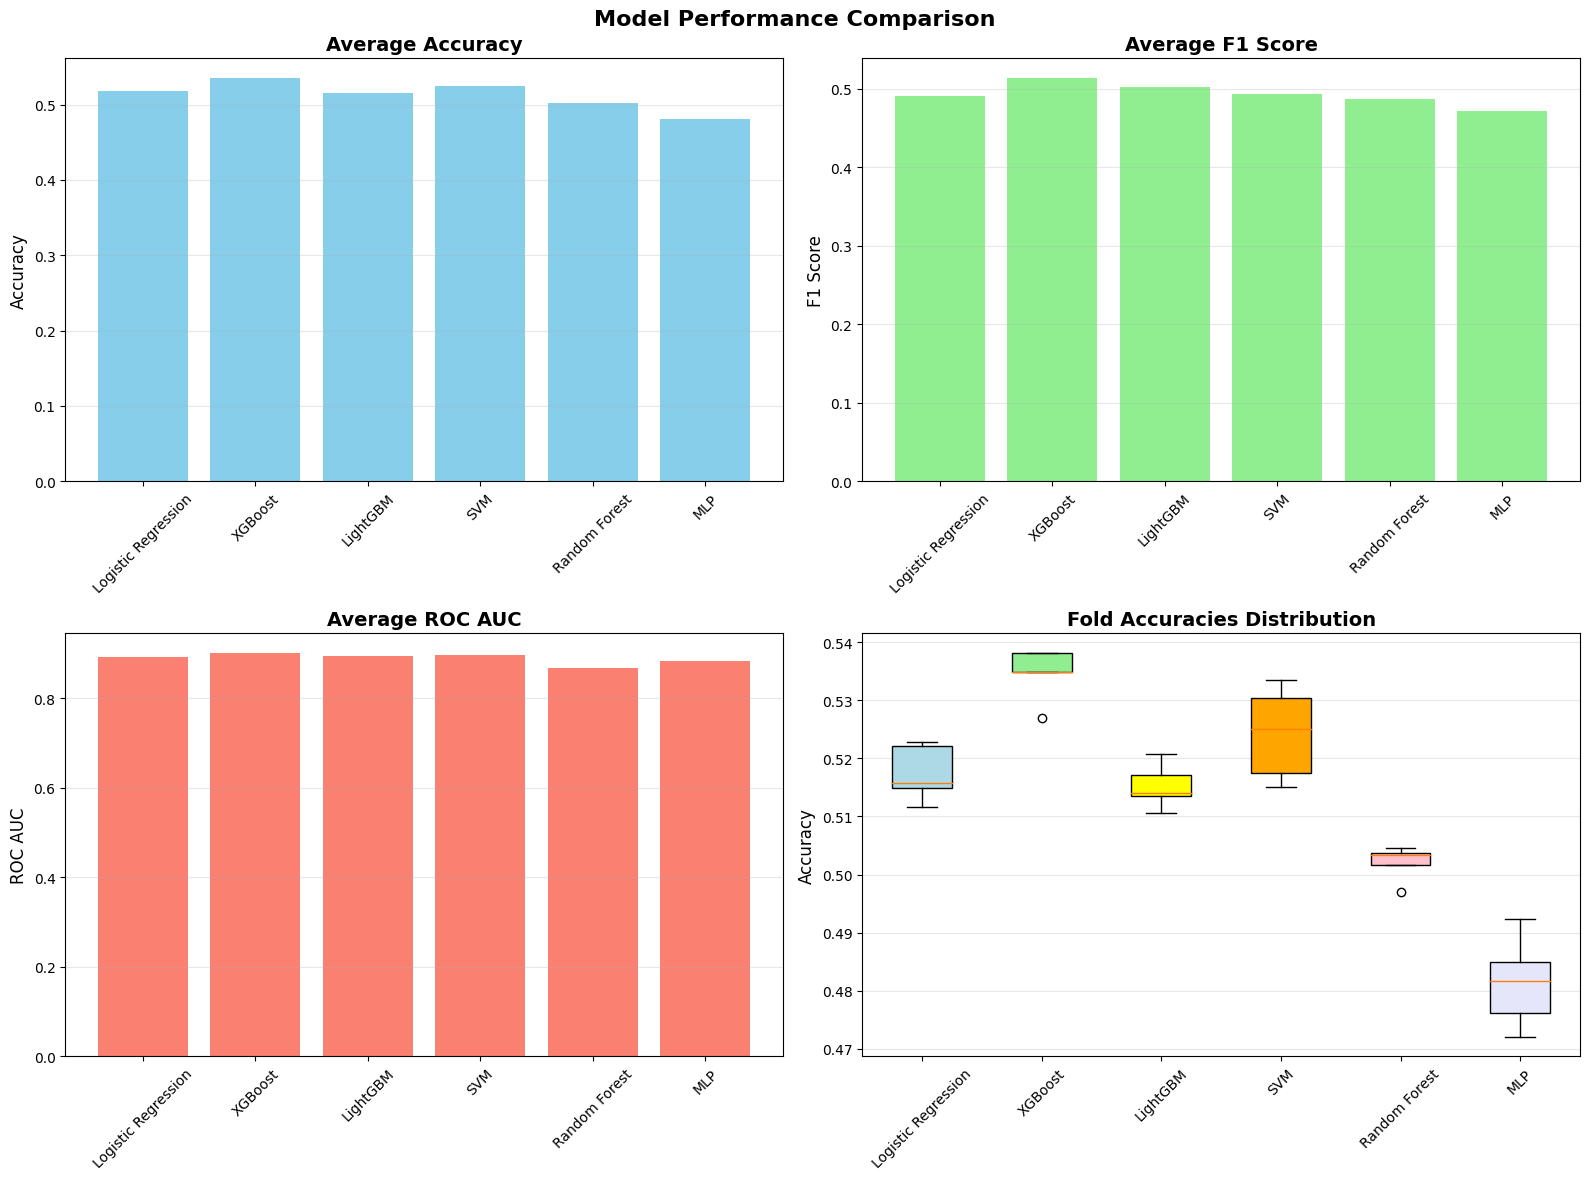

In [31]:
plt.figure(figsize=(14, 8))

# Tạo subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Bar chart cho Accuracy
axes[0, 0].bar(results_df['Model'], results_df['Accuracy'], color='skyblue')
axes[0, 0].set_title('Average Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Bar chart cho F1 Score
axes[0, 1].bar(results_df['Model'], results_df['F1_Score'], color='lightgreen')
axes[0, 1].set_title('Average F1 Score', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('F1 Score', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Bar chart cho ROC AUC
axes[1, 0].bar(results_df['Model'], results_df['ROC_AUC'], color='salmon')
axes[1, 0].set_title('Average ROC AUC', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('ROC AUC', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Box plot cho fold accuracies
box_data = [acc for acc in results_df['Fold_Accuracies']]
box = axes[1, 1].boxplot(box_data, labels=results_df['Model'], patch_artist=True)
for patch, color in zip(box['boxes'], ['lightblue', 'lightgreen', 'yellow', 'orange', 'pink', 'lavender']):
    patch.set_facecolor(color)
axes[1, 1].set_title('Fold Accuracies Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Accuracy', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
cv_plot_path = f'{output_dir}/08_cross_validation_plots.png'
plt.savefig(cv_plot_path, dpi=300, bbox_inches='tight')
plt.show()

## Train Best Model trên toàn bộ training data

In [32]:
# Lấy model object tốt nhất
best_model_object = models[best_model_name]

# Train trên toàn bộ training data
best_model_object.fit(X_train_scaled, y_train)

# Predict on training data
y_pred_train = best_model_object.predict(X_train_scaled)
y_pred_proba_train = best_model_object.predict_proba(X_train_scaled)

accuracy_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train, average='weighted')
roc_auc_train = roc_auc_score(y_train, y_pred_proba_train, multi_class='ovr')

print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Training F1 Score: {f1_train:.4f}")
print(f"Training ROC AUC: {roc_auc_train:.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_pred_train))

Training Accuracy: 0.7235
Training F1 Score: 0.7036
Training ROC AUC: 0.9694

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       500
           1       0.85      0.11      0.19      1098
           2       0.77      0.70      0.73      1018
           3       1.00      1.00      1.00       322
           4       0.95      0.97      0.96       310
           5       0.83      0.88      0.85      1157
           6       0.65      0.51      0.57      2069
           7       1.00      1.00      1.00       461
           8       0.80      0.76      0.78      1483
           9       0.73      0.74      0.74      2019
          10       0.61      0.84      0.71      3959

    accuracy                           0.72     14396
   macro avg       0.83      0.77      0.77     14396
weighted avg       0.74      0.72      0.70     14396



In [33]:
# Lưu predictions trên training set
train_predictions = pd.DataFrame({
    'true_class': y_train,
    'predicted_class': y_pred_train
})

for i in range(y_pred_proba_train.shape[1]):
    train_predictions[f'prob_class_{i}'] = y_pred_proba_train[:, i]

train_predictions.to_csv(f'{output_dir}/09_best_model_training_predictions.csv', index=False)
print("Best model training predictions saved!")

Best model training predictions saved!


## Feature Importance cho Best Model

In [34]:
print("\n=== FEATURE IMPORTANCE FOR BEST MODEL ===")

n_features = X_train_scaled.shape[1]
feature_names = [f'feature_{i}' for i in range(n_features)]

# Kiểm tra loại model để lấy feature importance phù hợp
if hasattr(best_model_object, 'feature_importances_'):
    # Tree-based models (XGBoost, Random Forest, LightGBM)
    importance_values = best_model_object.feature_importances_
    importance_type = f"{best_model_name} Feature Importance"
    
elif hasattr(best_model_object, 'coef_'):
    # Linear models (Logistic Regression, SVM với kernel linear)
    if len(best_model_object.coef_.shape) > 1:
        # Multi-class: lấy giá trị trung bình tuyệt đối của tất cả các class
        importance_values = np.mean(np.abs(best_model_object.coef_), axis=0)
    else:
        # Binary classification
        importance_values = np.abs(best_model_object.coef_[0])
    importance_type = f"{best_model_name} Coefficient Magnitude"
    
else:
    # Neural networks và các model không có feature importance trực tiếp
    print(f"{best_model_name} không có feature importance trực tiếp")
    # Tạo giá trị importance ngẫu nhiên cho visualization (chỉ để minh họa)
    importance_values = np.random.rand(len(feature_names))
    importance_type = f"Random (Fallback for {best_model_name})"

# Tạo DataFrame với feature importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_values
}).sort_values('importance', ascending=False)

print(f"\nFeature importance type: {importance_type}")
print("\nTop 15 most important features:")
print(feature_importance.head(15))

# Lưu feature importance
feature_importance.to_csv(f'{output_dir}/10_best_model_feature_importance.csv', index=False)
print(f"\nFeature importance saved to: {output_dir}/10_best_model_feature_importance.csv")


=== FEATURE IMPORTANCE FOR BEST MODEL ===

Feature importance type: XGBoost Feature Importance

Top 15 most important features:
       feature  importance
12  feature_12    0.069689
24  feature_24    0.066788
16  feature_16    0.056599
7    feature_7    0.056082
15  feature_15    0.055379
6    feature_6    0.051666
2    feature_2    0.043627
19  feature_19    0.039437
8    feature_8    0.034281
0    feature_0    0.029099
17  feature_17    0.027847
22  feature_22    0.027487
4    feature_4    0.027162
1    feature_1    0.026447
38  feature_38    0.026305

Feature importance saved to: ../../../exps3/featbase_3/10_best_model_feature_importance.csv


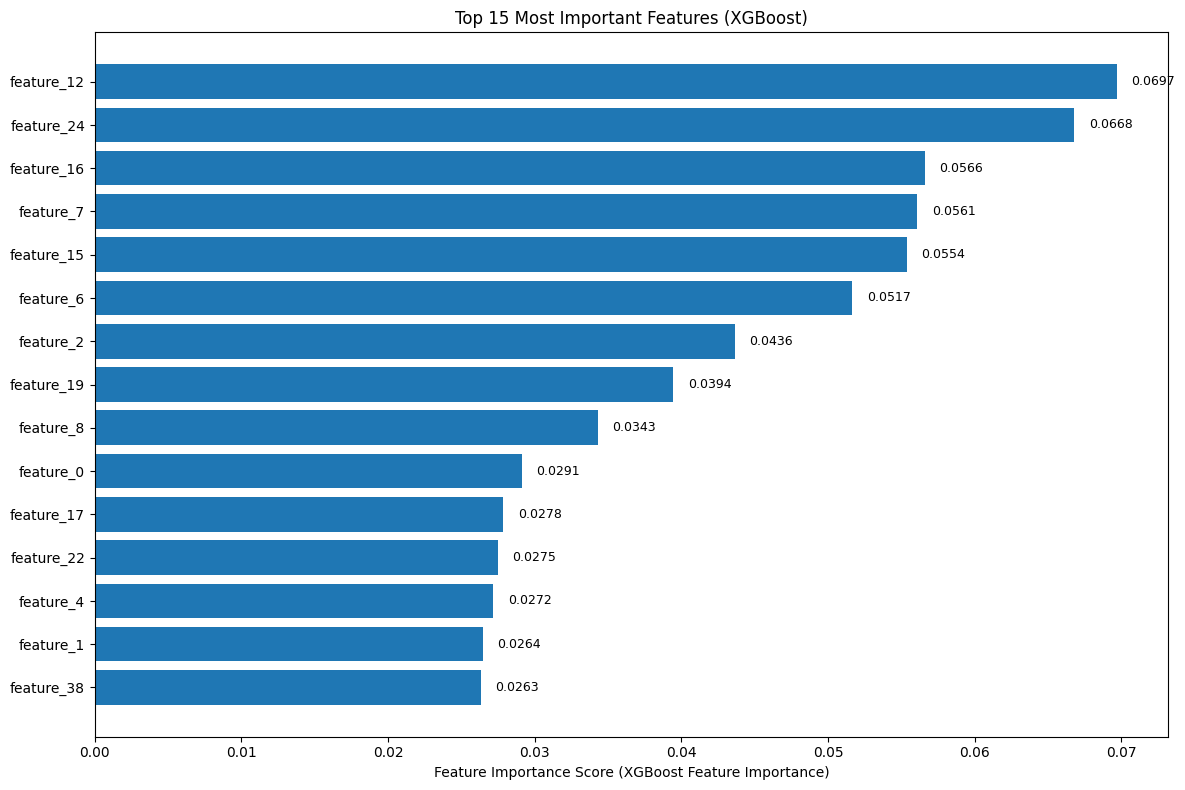

In [35]:
# Visualization feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)

bars = plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel(f'Feature Importance Score ({importance_type})')
plt.title(f'Top 15 Most Important Features ({best_model_name})')
plt.gca().invert_yaxis()

# Thêm giá trị trên bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
feature_importance_plot_path = f'{output_dir}/11_best_model_feature_importance_plot.png'
plt.savefig(feature_importance_plot_path, dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# Dự đoán trên test set
test_predictions = best_model_object.predict(X_test_scaled)
test_probabilities = best_model_object.predict_proba(X_test_scaled)

print(f"Test predictions shape: {test_predictions.shape}")

# Lưu test predictions chi tiết
test_predictions_df = pd.DataFrame({
    'predicted_class': test_predictions
})

for i in range(test_probabilities.shape[1]):
    test_predictions_df[f'prob_class_{i}'] = test_probabilities[:, i]

test_predictions_df.to_csv(f'{output_dir}/12_test_predictions_detailed.csv', index=False)
print("Detailed test predictions saved!")

Test predictions shape: (3600,)
Detailed test predictions saved!


In [37]:
# Tạo submission với ID từ test_df gốc
submission = pd.DataFrame({
    "Id": test_df["Id"], 
    "Class": test_predictions
})

# Kiểm tra số lượng
print(f"Submission shape: {submission.shape}")
print(f"Unique Ids: {submission['Id'].nunique()}")
print(f"Id range: {submission['Id'].min()} - {submission['Id'].max()}")

print("\nPrediction distribution:")
pred_dist = submission['Class'].value_counts().sort_index()
print(pred_dist)

# Lưu prediction distribution
pred_dist.to_csv(f'{output_dir}/13_prediction_distribution.csv')
print("\nPrediction distribution saved!")

# Lưu submission file
submission.to_csv(f'{output_dir}/14_final_submission.csv', index=False)
submission.to_csv("submission.csv", index=False)
print("\nSubmission file 'submission.csv' created.")

Submission shape: (3600, 2)
Unique Ids: 3600
Id range: 14397 - 17996

Prediction distribution:
0      146
1       20
2      225
3       76
4       85
5      291
6      415
7      106
8      315
9      496
10    1425
Name: Class, dtype: int64

Prediction distribution saved!

Submission file 'submission.csv' created.


In [38]:
# Hiển thị các file đã tạo
print(f"\n=== FILES CREATED IN '{output_dir}' ===")
files = os.listdir(output_dir)
for i, file in enumerate(sorted(files), 1):
    print(f"{i:2d}. {file}")

print(f"\nTotal files created: {len(files)}")


=== FILES CREATED IN '../../../exps3/featbase_3' ===
 1. 01_original_test.csv
 2. 01_original_train.csv
 3. 02_after_missing_values_test.csv
 4. 02_after_missing_values_train.csv
 5. 03_after_encoding_test.csv
 6. 03_after_encoding_train.csv
 7. 041_after_feature_engineering_test.csv
 8. 041_after_feature_engineering_train.csv
 9. 042_after_feature_selection_test.csv
10. 042_after_feature_selection_train.csv
11. 05_features_before_scaling_test.csv
12. 05_features_before_scaling_train.csv
13. 05_target_train.csv
14. 06_features_after_scaling_test.csv
15. 06_features_after_scaling_train.csv
16. 07_cross_validation_results.csv
17. 08_cross_validation_plots.png
18. 08_feature_importance.csv
19. 09_best_model_training_predictions.csv
20. 10_best_model_feature_importance.csv
21. 11_best_model_feature_importance_plot.png
22. 12_test_predictions_detailed.csv
23. 13_prediction_distribution.csv
24. 14_final_submission.csv

Total files created: 24
